Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Datasets

In [2]:
df1 = pd.read_csv("historical_data.csv")
df2 = pd.read_csv("fear_greed_index.csv")

print(df1.shape)
print(df2.shape)

df1.head()

(211224, 16)
(2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Clean Column Names

In [3]:
df1.columns = df1.columns.str.lower().str.replace(" ", "_")
df2.columns = df2.columns.str.lower().str.replace(" ", "_")

print(df1.columns)
print(df2.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


Convert Timestamps

In [4]:
df1["timestamp_ist"] = pd.to_datetime(df1["timestamp_ist"], dayfirst=True)

df1["date"] = df1["timestamp_ist"].dt.date

df2["date"] = pd.to_datetime(df2["date"]).dt.date

Merge Datasets

In [5]:
df3 = pd.merge(df1, df2, on="date", how="left")

print(df3.shape)

df3.head()

(211224, 20)


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp_x,date,timestamp_y,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


Data Quality Checks

In [6]:
df3.isnull().sum()

print("duplicate rows:", df3.duplicated().sum())

df3["classification"] = df3["classification"].fillna("unknown")
df3["value"] = df3["value"].fillna(df3["value"].median())

duplicate rows: 0


Dataset Overview

In [7]:
print("total trades:", len(df3))
print("unique traders:", df3["account"].nunique())
print("unique coins:", df3["coin"].nunique())

total trades: 211224
unique traders: 32
unique coins: 246


Feature Engineering

In [8]:
df3["is_profit"] = df3["closed_pnl"] > 0

trades_per_day = df3.groupby("date").size()

long_short_ratio = df3["side"].value_counts(normalize=True)

print(long_short_ratio)


side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


Performance by Market Sentiment

In [9]:
pnl_by_sentiment = df3.groupby("classification")["closed_pnl"].mean()

print(pnl_by_sentiment)

win_rate = df3.groupby("classification")["is_profit"].mean()

print(win_rate)

classification
Extreme Fear       34.537862
Extreme Greed      67.892861
Fear               54.290400
Greed              42.743559
Neutral            34.307718
unknown          7078.665688
Name: closed_pnl, dtype: float64
classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
unknown          1.000000
Name: is_profit, dtype: float64


Trader Behavior Analysis

In [10]:
trade_behavior = df3.groupby(["classification","side"]).size().unstack()

print(trade_behavior)

avg_size = df3.groupby("classification")["size_usd"].mean()

print(avg_size)

side                BUY     SELL
classification                  
Extreme Fear    10935.0  10465.0
Extreme Greed   17940.0  22052.0
Fear            30270.0  31567.0
Greed           24576.0  25727.0
Neutral         18969.0  18717.0
unknown             6.0      NaN
classification
Extreme Fear      5349.731843
Extreme Greed     3112.251565
Fear              7816.109931
Greed             5736.884375
Neutral           4782.732661
unknown          14778.143333
Name: size_usd, dtype: float64


Top Traders

In [11]:
top_traders = (
    df3.groupby("account")["closed_pnl"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_traders

account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: closed_pnl, dtype: float64

Coin Activity

In [12]:
coin_activity = (
    df3.groupby("coin")
    .size()
    .sort_values(ascending=False)
)

coin_activity.head(10)

coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
dtype: int64

Trade Size Segmentation

In [13]:
df3["size_segment"] = pd.qcut(
    df3["size_usd"],
    q=4,
    labels=["small","medium","large","very_large"]
)

df3["size_segment"].value_counts()

size_segment
small         52829
large         52806
very_large    52806
medium        52783
Name: count, dtype: int64

Profit by Trade Size

In [14]:
size_perf = df3.groupby("size_segment")["closed_pnl"].mean()

size_perf

C:\Users\mudha\AppData\Local\Temp\ipykernel_22804\3466241407.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_perf = df3.groupby("size_segment")["closed_pnl"].mean()


size_segment
small           2.168210
medium          6.596610
large          22.015666
very_large    164.217447
Name: closed_pnl, dtype: float64

Trader Consistency Analysis

In [15]:
trader_stats = df3.groupby("account").agg({
    "closed_pnl":["mean","std","count"]
})

trader_stats.columns = ["avg_pnl","pnl_std","trade_count"]

trader_stats.head()

,avg_pnl,pnl_std,trade_count
account,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,4692.452329,3818
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,134.073473,7280
0x271b280974205ca63b716753467d5a371de622ab,-18.492043,542.182659,3809
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,113.269353,13311
0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,255.829091,3239


Risk Adjusted Trader Performance

In [16]:
risk_perf = df3.groupby("account")["closed_pnl"].agg(["mean","std"])

risk_perf["risk_adjusted_return"] = risk_perf["mean"] / risk_perf["std"]

risk_perf = risk_perf.replace([np.inf,-np.inf], np.nan)

risk_perf = risk_perf.dropna()

risk_perf.sort_values("risk_adjusted_return", ascending=False).head(10)

,mean,std,risk_adjusted_return
account,,,
0xae5eacaf9c6b9111fd53034a602c192a04e082ed,120.507317,474.809837,0.253801
0x6d6a4b953f202f8df5bed40692e7fd865318264a,111.519197,468.995982,0.237783
0x420ab45e0bd8863569a5efbb9c05d91f40624641,520.902331,2228.336140,0.233763
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,38.319560,172.520773,0.222116
0x430f09841d65beb3f27765503d0f850b8bce7713,336.735548,1649.497580,0.204144
0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,255.829091,0.203538
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d,41.474096,220.387735,0.188187
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,155.589314,855.354003,0.181900
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0,174.691809,976.068751,0.178975


Sentiment Risk Analysis

In [17]:
sentiment_risk = df3.groupby("classification")["closed_pnl"].agg(["mean","std"])

sentiment_risk["risk_metric"] = sentiment_risk["mean"] / sentiment_risk["std"]

sentiment_risk

,mean,std,risk_metric
classification,,,
Extreme Fear,34.537862,1136.056091,0.030402
Extreme Greed,67.892861,766.828294,0.088537
Fear,54.290400,935.355438,0.058043
Greed,42.743559,1116.028390,0.038300
Neutral,34.307718,517.122220,0.066344
unknown,7078.665688,5735.884239,1.234102


PnL vs Sentiment Visualization

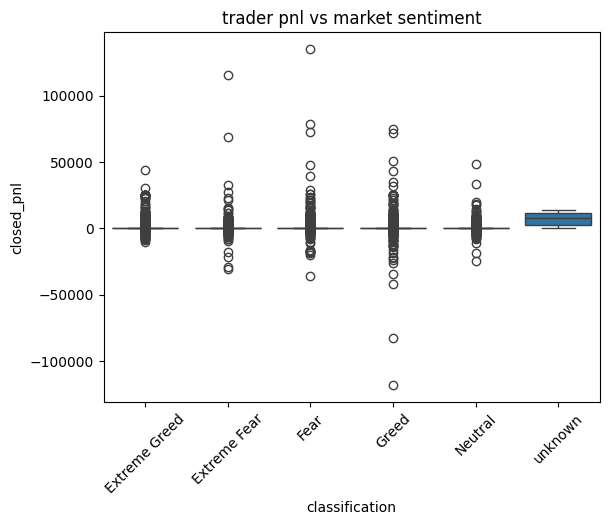

In [18]:
sns.boxplot(data=df3, x="classification", y="closed_pnl")

plt.title("trader pnl vs market sentiment")

plt.xticks(rotation=45)

plt.show()

Average Trade Size by Sentiment

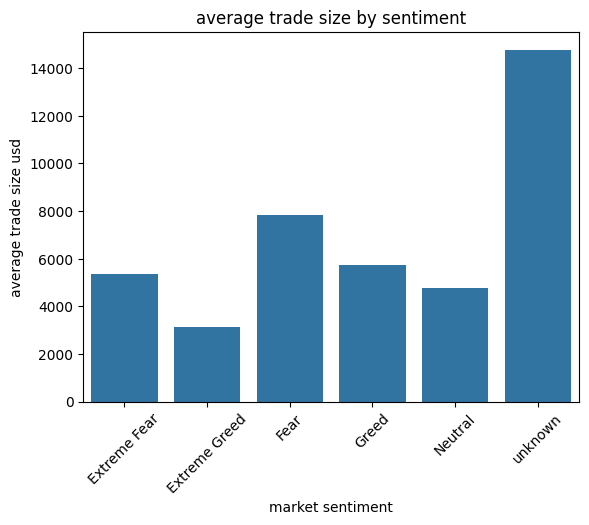

In [19]:
avg_size = df3.groupby("classification")["size_usd"].mean().reset_index()

sns.barplot(data=avg_size, x="classification", y="size_usd")

plt.title("average trade size by sentiment")

plt.xlabel("market sentiment")

plt.ylabel("average trade size usd")

plt.xticks(rotation=45)

plt.show()

PnL Distribution

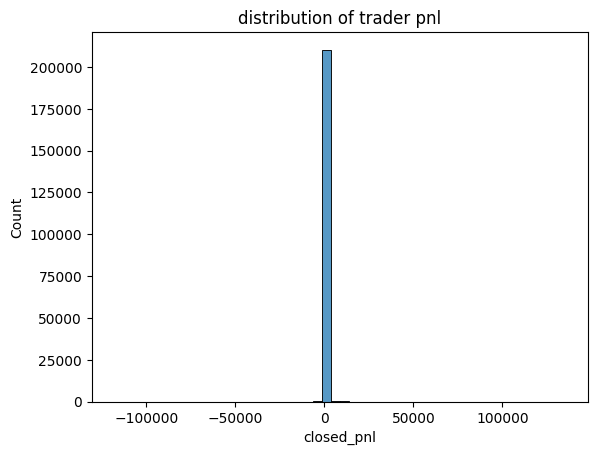

In [20]:
sns.histplot(df3["closed_pnl"], bins=50)

plt.title("distribution of trader pnl")

plt.show()

Risk Adjusted Performance Distribution

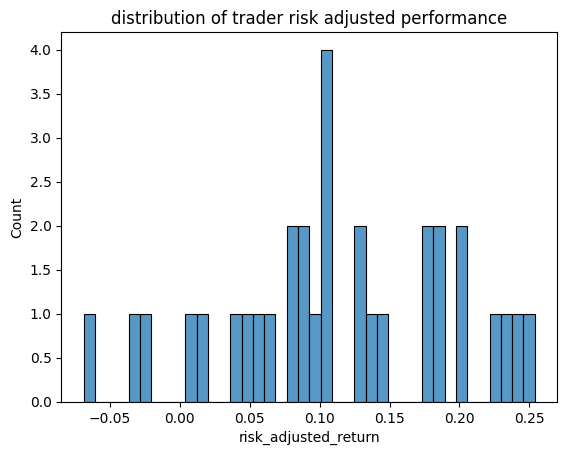

In [22]:
sns.histplot(risk_perf["risk_adjusted_return"], bins=40)

plt.title("distribution of trader risk adjusted performance")

plt.show()

Key Insights

Trader profitability tends to be stronger during fear sentiment periods, suggesting traders may exploit market dips for profitable entry points.

Trading activity and trade sizes increase during extreme sentiment conditions, indicating higher participation and risk-taking.

Buy orders become more frequent during fear periods, reflecting accumulation strategies during market downturns.

Larger trade sizes generate higher average profits but also introduce greater variability in outcomes.

A relatively small group of traders contributes a large portion of total profits.

Risk-adjusted performance also appears stronger during fear sentiment regimes, indicating better reward relative to risk.

Strategy Recommendations

During fear sentiment periods, traders may consider moderately increasing trade frequency and position sizes to capture potential rebound opportunities.

During greed sentiment periods, traders should reduce leverage exposure and apply tighter risk management since profitability becomes less consistent despite higher trading activity.

Conclusion

This analysis explored the relationship between trader behavior and Bitcoin market sentiment using the Fear & Greed Index.

The findings suggest that trader strategies shift depending on market psychology. Fear periods appear to provide better risk-adjusted opportunities, while greed periods lead to higher trading activity but less stable profitability.

Understanding these sentiment-driven patterns can help inform more adaptive trading strategies in cryptocurrency markets.